In [1]:
import numpy as np
import pandas as pd
import os
import random
import json
from collections import defaultdict
from itertools import chain

# scikit-learn 相关
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (classification_report, confusion_matrix,
                            accuracy_score, roc_curve, auc, roc_auc_score)
from sklearn.preprocessing import label_binarize
from sklearn.multiclass import OneVsRestClassifier
from sklearn.feature_selection import RFE, SequentialFeatureSelector
from sklearn.model_selection import learning_curve

from imblearn.over_sampling import SMOTE, ADASYN
from sklearn.base import clone
# 可视化相关
import matplotlib.pyplot as plt
import seaborn as sns

# 设置全局随机种子
np.random.seed(11)
random.seed(11)
os.environ['PYTHONHASHSEED'] = str(11)

# 其他库（如果适用，请取消注释）
# import tensorflow as tf
# tf.random.set_seed(11)
# import torch
# torch.manual_seed(11)

# 加载与保存模型等操作
import pickle
#import torch

import xgboost as xgb
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import LogisticRegression

from sklearn.model_selection import KFold
from sklearn.metrics import roc_auc_score
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import math

In [2]:
input_dir = "/mnt/f/精浆文章/20250310/"
output_dir = "/mnt/f/精浆文章/20250310/pr_article/"
#if not exists  create output_dir
if not os.path.exists(output_dir):
    os.makedirs(output_dir)
#set working directory
os.chdir(output_dir)



In [3]:
clin=pd.read_csv(input_dir+"clin.txt",index_col=0,sep="\t")
print(clin)
mlnc_expression=pd.read_csv(input_dir+"Genes_TPM.txt",index_col=0,sep="\t")
print(mlnc_expression)

               num  num_group    PR  PR_NP  PR_NP_group  PR_group
samplename                                                       
CF-N007      749.3          0  87.0   89.6            0         0
CF-N012     1237.0          0  45.0   51.6            0         0
CF-N018      197.2          0  33.5   34.6            1         0
CF-N027      361.3          0  42.9   45.7            0         0
CF-N031      120.3          0  55.0   59.3            0         0
...            ...        ...   ...    ...          ...       ...
CF-W127        0.0          1   0.0    0.0            1         1
CF-W128        0.0          1   0.0    0.0            1         1
CF-W129        0.0          1   0.0    0.0            1         1
CF-W130        0.0          1   0.0    0.0            1         1
CF-W131        0.0          1   0.0    0.0            1         1

[431 rows x 6 columns]
              CF-N007  CF-N012  CF-N018  CF-N027  CF-N031  CF-N032  CF-N034  \
Gene                                   

In [4]:
# feature_selection=pd.read_csv(input_dir+"act_feature.txt",sep="\t",header=None)
# feature_selection = feature_selection[0].tolist()
# feature_selection[0:5]

feature_selection=pd.read_csv(input_dir+"PR_selected_features_continuous.csv")
feature_selection = feature_selection["feature"].tolist()
feature_selection[0:5]

['KIAA1210', 'RPL31', 'SGK2', 'PTCH2', 'KAT6A']

In [5]:
#col num_group = 0 or 1 
#clin = clin[clin["PR_NP_group"].isin([0,1])]
usesamplename=list(mlnc_expression.columns.intersection(clin.index))
#use usesamplename to select mlnc_expression columns
mlnc_expression_use=mlnc_expression[usesamplename]
#use usesamplename to select clin rows
clin_use=clin.loc[usesamplename]

#filter rowname feature_selection
mlnc_expression_use = mlnc_expression_use.loc[feature_selection]
mlnc_expression_use

,CF-N007,CF-N012,CF-N018,CF-N027,CF-N031,CF-N032,CF-N034,CF-N035,CF-N036,CF-N038,...,CF-W120,CF-W121,CF-W122,CF-W123,CF-W124,CF-W127,CF-W128,CF-W129,CF-W130,CF-W131
Gene,,,,,,,,,,,,,,,,,,,,,
KIAA1210,0.35,0.63,1.00,0.22,0.18,0.31,0.08,0.21,1.01,0.25,...,0.10,0.04,0.05,0.03,0.03,0.00,0.00,0.06,0.04,0.04
RPL31,4535.41,2697.22,4267.53,4272.76,5076.46,4175.00,3853.66,4781.81,3361.22,4577.19,...,3639.14,3571.55,3561.11,2919.36,3051.78,2831.10,5732.79,4759.12,3479.59,3134.39
SGK2,0.06,0.26,0.84,0.30,0.44,0.25,0.00,0.00,1.08,0.14,...,1.62,0.12,0.11,0.55,0.20,0.00,0.18,0.20,0.00,0.05
PTCH2,24.76,22.14,36.85,16.14,37.91,23.05,22.95,26.04,22.56,9.08,...,24.00,31.10,26.97,28.31,11.78,12.59,27.99,50.98,14.88,18.85
KAT6A,15.25,21.06,13.18,19.97,18.07,25.91,17.22,22.93,28.38,17.60,...,19.37,13.97,15.22,20.42,15.08,21.75,18.44,18.43,12.23,16.79
SUPT16H,15.52,23.79,20.94,21.93,22.54,27.45,20.01,27.67,27.91,22.49,...,29.35,19.09,19.48,29.62,20.41,28.28,23.80,22.80,20.94,20.38
KLHDC9,5.76,6.77,7.24,6.99,5.36,9.86,9.57,9.56,12.45,11.20,...,11.48,8.67,8.52,11.63,8.08,9.15,8.33,8.34,10.81,8.28
ARCN1,80.52,124.60,103.77,131.91,122.73,153.14,142.69,148.87,151.22,130.72,...,125.40,93.25,101.83,153.92,123.45,138.68,113.33,109.54,102.57,95.13
FGD1,0.30,0.33,0.35,0.50,0.41,0.43,0.35,0.29,0.68,0.48,...,0.77,0.14,0.28,0.47,0.60,0.47,0.37,0.74,0.23,0.51


In [6]:
detected_in_samples = np.sum(mlnc_expression_use > 0, axis=1)
detected_in_samples

Gene
KIAA1210           358
RPL31              421
SGK2               380
PTCH2              421
KAT6A              421
SUPT16H            421
KLHDC9             421
ARCN1              421
FGD1               421
LINC00930          414
ZC4H2              421
TTC6               421
AMPD2              421
ENSG00000235979    321
PCDHGA9            228
METAP2             421
C12orf76           420
KCTD3              421
MRPL20-DT          413
ENSG00000285953    254
SGCB               421
ARHGAP39           420
TARBP1             421
USP24              421
WDR47              421
BHLHE40-AS1        418
FKBP14-AS1         389
ENSG00000262445    211
ENSG00000289063    281
ENSG00000248736    226
ARPC4-TTLL3        336
dtype: int64

In [7]:
import numpy as np
import pandas as pd
from sklearn.svm import SVR
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_percentage_error
from scipy.stats import pearsonr

import numpy as np
import pandas as pd
#preprocessing
from sklearn import preprocessing
#LinearRegression
from sklearn.linear_model import LinearRegression
# mean_squared_error and mean_absolute_error and r2_score 
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [8]:
mlnc_expression_use_filtered=mlnc_expression_use
X=mlnc_expression_use_filtered.T
y=clin_use["PR"]
name = "PR"
Y = y
X = np.asarray(X)
X = np.nan_to_num(X)
y = np.asarray(Y)
min_max_scaler = preprocessing.MinMaxScaler()
X = min_max_scaler.fit_transform(X)
X = np.asarray(X,dtype=np.float32)

In [9]:


kf = KFold(n_splits=10, shuffle=True, random_state=42)
#kf = KFold(n_splits=10, shuffle=True)
results = {
    'Fold': [],
    'R2': [],
    'Pearson pvalue': [],
    'Pearson correlation': [],
    'RMSE': [],
    'MSE': []
}


overall_predictions = np.zeros_like(y)

fold = 1
for train_index, test_index in kf.split(X):
    print(f'Fold {fold}')
    #print('Training samples:', train_index)
    #X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    # sc = StandardScaler() 
    # sc.fit(X_train) 
    # X_train = sc.transform(X_train) 
    # X_test = sc.transform(X_test) 
    
    #model = SVR()
    model  = LinearRegression()
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mse = mean_squared_error(y_test, y_pred)
    correlation, p_value = pearsonr(y_test, y_pred)
    
    results['Fold'].append(fold)
    results['R2'].append(r2)
    results['Pearson pvalue'].append(p_value)
    results['Pearson correlation'].append(correlation)
    results['RMSE'].append(rmse)
    results['MSE'].append(mse)
    
    
    overall_predictions[test_index] = y_pred
    fold += 1

results_df = pd.DataFrame(results)
results_df.to_csv(output_dir+name+'_cross_validation_results.csv', index=False)

# 计算整体样本的R2、p值和RMSE
overall_r2 = r2_score(y, overall_predictions)
overall_rmse = np.sqrt(mean_squared_error(y, overall_predictions))
overall_p_value = pearsonr(y, overall_predictions)[1]
overall_correlation = pearsonr(y, overall_predictions)[0]
overall_mse = mean_squared_error(y, overall_predictions)


overall_results = {
    'Overall R2': [overall_r2],
    'Overall Pearson pvalue': [overall_p_value],
    'Overall Pearson correlation': [overall_correlation],
    'Overall RMSE': [overall_rmse],
    'Overall MSE': [overall_mse]
}

overall_results_df = pd.DataFrame(overall_results)
overall_results_df.to_csv(output_dir+name+'_overall_results.csv', index=False)

print('Cross-validation results:')
print(results_df)
print('Overall results:')
print(overall_results_df)

print('mean R2:', results_df['R2'].mean())
print('mean RMSE:', results_df['RMSE'].mean())
print('mean MSE:', results_df['MSE'].mean())
print('mean Pearson correlation:', results_df['Pearson correlation'].mean())

#merge y and overall_predictions and save
y_df = pd.DataFrame(y, columns=['true'])
overall_predictions_df = pd.DataFrame(overall_predictions, columns=['predicted'])
pred_and_true = pd.concat([y_df, overall_predictions_df], axis=1)
#row name is sample name
pred_and_true.index = usesamplename
pred_and_true.to_csv(output_dir+name+'_predicted_and_true.csv')



Fold 1
Fold 2
Fold 3
Fold 4
Fold 5
Fold 6
Fold 7
Fold 8
Fold 9
Fold 10
Cross-validation results:
   Fold        R2  Pearson pvalue  Pearson correlation       RMSE         MSE
0     1  0.807012    1.115191e-16             0.903512  11.517353  132.649418
1     2  0.780981    3.255631e-15             0.889874  12.507724  156.443169
2     3  0.752859    4.619369e-14             0.873253  11.855863  140.561497
3     4  0.543903    1.521326e-09             0.776387  11.786936  138.931851
4     5  0.681993    1.518476e-11             0.826789  14.286071  204.091830
5     6  0.510854    8.698546e-08             0.717955  12.636104  159.671124
6     7  0.640872    7.326547e-11             0.811160  12.826951  164.530672
7     8  0.736595    2.697870e-13             0.860723  12.101777  146.453001
8     9  0.845933    2.584487e-19             0.932685   8.955631   80.203329
9    10  0.775469    6.659977e-15             0.885631  12.373048  153.092327
Overall results:
   Overall R2  Overall Pears

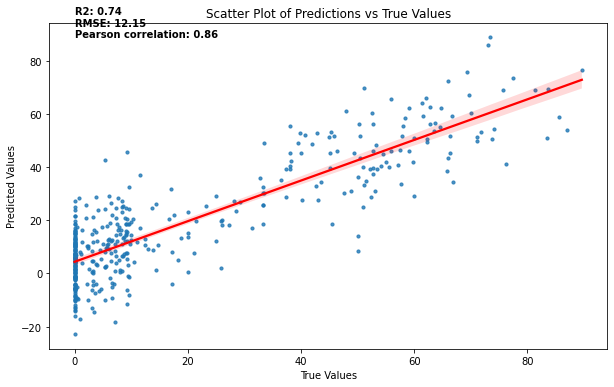

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# 绘制散点图并生成拟合直线
# 创建一个图和坐标轴
plt.figure(figsize=(10, 6))
sns.regplot(x=y, y=overall_predictions, scatter_kws={'s':10}, line_kws={"color":"red"})
#sns.regplot(x=y, y=overall_predictions, scatter=False, line_kws={"color":"red"})
#sns.kdeplot(y, overall_predictions, cmap="Blues", shade=True, shade_lowest=False)
#dataframe = pd.DataFrame({'x': y, 'y': overall_predictions})
plot_data = pd.DataFrame({'x': y, 'y': overall_predictions})
#writing to csv
plot_data.to_csv(output_dir+name+'_scatter_plot.csv')

# 计算整体样本的R2和RMSE
overall_r2 = r2_score(y, overall_predictions)
overall_rmse = np.sqrt(mean_squared_error(y, overall_predictions))

# 在图上显示R2和RMSE Pearson correlation pvalue
#plt.text(min(y), max(overall_predictions)-200, f'R2: {overall_r2:.2f}\nRMSE: {overall_rmse:.2f}\nPearson correlation: {overall_correlation:.2f}\nP value: {overall_p_value:.2f}',
#         horizontalalignment='left', size='medium', color='black', weight='semibold')
plt.text(min(y), max(overall_predictions), f'R2: {overall_r2:.2f}\nRMSE: {overall_rmse:.2f}\nPearson correlation: {overall_correlation:.2f}',
         horizontalalignment='left', size='medium', color='black', weight='semibold')

# 设置图表标签和标题
plt.xlabel('True Values')
plt.ylabel('Predicted Values')
plt.title('Scatter Plot of Predictions vs True Values')
#save as pdf
plt.savefig(output_dir+name+'_scatter_plot.pdf')

# 显示图表
plt.show()




In [11]:
mlnc_expression_use_filtered=mlnc_expression_use
X=mlnc_expression_use_filtered.T
y=clin_use["PR_group"]
name = "PR_group"
Y = y
X = np.asarray(X)
X = np.nan_to_num(X)
y = np.asarray(Y)
min_max_scaler = preprocessing.MinMaxScaler()
X = min_max_scaler.fit_transform(X)
X = np.asarray(X,dtype=np.float32)

In [12]:
model_lists = {
    #'RF':RandomForestClassifier(n_estimators=100, random_state=42),
    #'XGB':xgb.XGBClassifier(n_estimators=100, random_state=42),
    'SVC':SVC(kernel='linear', C=0.01, random_state=42,probability=True,gamma='auto'),
    #'LR':LogisticRegression(random_state=42),
}

In [13]:
kf = KFold(n_splits=10, shuffle=True, random_state=42)
results = {
    'Fold': [],
    'train auc': [],
    'test auc': []
}

# 用于存储所有折的真实值、预测概率和折号
true_values = []
predicted_probabilities = []
fold_indices = []

fold = 1
for train_index, test_index in kf.split(X):
    print(f'Fold {fold}')
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    
    sc = StandardScaler() 
    sc.fit(X_train) 
    X_train = sc.transform(X_train) 
    X_test = sc.transform(X_test) 

    model = LogisticRegression(random_state=42)
    model.fit(X_train, y_train)
    
    y_test_pred_prob = model.predict_proba(X_test)
    y_train_pred_prob = model.predict_proba(X_train)
    train_auc = roc_auc_score(y_train, y_train_pred_prob[:, 1])
    test_auc = roc_auc_score(y_test, y_test_pred_prob[:, 1])
    
    results['Fold'].append(fold)
    results['train auc'].append(train_auc)
    results['test auc'].append(test_auc)

    true_values.extend(y_test)
    predicted_probabilities.extend(y_test_pred_prob[:, 1])
    fold_indices.extend([fold] * len(test_index))
    
    fold += 1

results_df = pd.DataFrame(results)
results_df.to_csv(output_dir+name + '_cross_validation_results.csv', index=False)

# 将所有真实值、预测概率和折号转换为数组
true_values = np.array(true_values)
predicted_probabilities = np.array(predicted_probabilities)
fold_indices = np.array(fold_indices)

# 计算整体样本的auc
overall_auc = roc_auc_score(true_values, predicted_probabilities)

overall_results = {
    'Overall auc': [overall_auc]
}

overall_results_df = pd.DataFrame(overall_results)
overall_results_df.to_csv(output_dir+name + '_overall_results.csv', index=False)

print('Cross-validation results:')
print(results_df)
print('Overall results:')
print(overall_results_df)

print('mean test auc:', results_df['test auc'].mean())

# 合并 y、overall_predictions 和 fold_indices 并保存
y_df = pd.DataFrame(true_values, columns=['true'])
overall_predictions_df = pd.DataFrame(predicted_probabilities, columns=['predicted'])
fold_indices_df = pd.DataFrame(fold_indices, columns=['fold'])
pred_and_true = pd.concat([y_df, overall_predictions_df, fold_indices_df], axis=1)
pred_and_true.index = usesamplename
pred_and_true.to_csv(output_dir+name + '_predicted_and_true.csv')

Fold 1
Fold 2
Fold 3
Fold 4
Fold 5
Fold 6
Fold 7
Fold 8
Fold 9
Fold 10
Cross-validation results:
   Fold  train auc  test auc
0     1   0.990901  0.978571
1     2   0.992908  0.967593
2     3   0.990341  0.969388
3     4   0.988383  1.000000
4     5   0.990717  0.977778
5     6   0.989677  0.918367
6     7   0.989693  0.996633
7     8   0.990036  0.977778
8     9   0.989921  0.991202
9    10   0.988568  1.000000
Overall results:
   Overall auc
0     0.976537
mean test auc: 0.9777310021434445


In [14]:
# 显示 pred_and_true DataFrame
print(pred_and_true.head())

         true  predicted  fold
CF-N007     0   0.483969     1
CF-N012     0   0.019645     1
CF-N018     0   0.041143     1
CF-N027     0   0.086344     1
CF-N031     0   0.476499     1


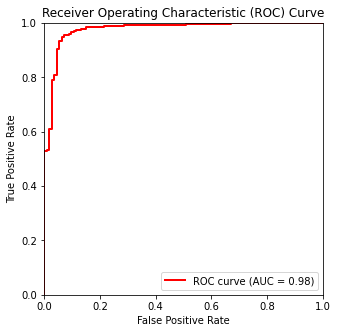

In [15]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# 从 pred_and_true DataFrame 中提取真实值和预测概率
true_values = pred_and_true['true'].values
predicted_probabilities = pred_and_true['predicted'].values

# 计算 ROC 曲线
fpr, tpr, thresholds = roc_curve(true_values, predicted_probabilities)
roc_auc = auc(fpr, tpr)

# 创建图形
plt.figure(figsize=(5, 5))

# 绘制 ROC 曲线
plt.plot(fpr, tpr, color='red', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')

# 添加标题和标签
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')


# 添加图例
plt.legend(loc='lower right')
# 设置坐标范围
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
#save as pdf
plt.savefig(output_dir+name+'_all_roc_plot.pdf')
# 显示图形
plt.show()

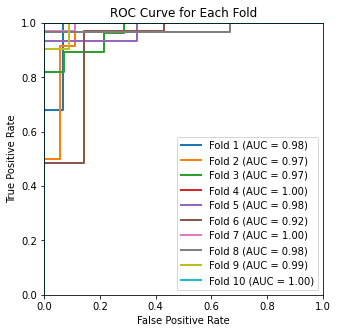

In [16]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# 读取 pred_and_true DataFrame
pred_and_true = pd.read_csv(output_dir+name + '_predicted_and_true.csv')

# 获取所有折号
folds = pred_and_true['fold'].unique()

# 创建图形
plt.figure(figsize=(5, 5))

# 遍历每个折号，绘制每个折的ROC曲线
for fold in folds:
    fold_data = pred_and_true[pred_and_true['fold'] == fold]
    true_values = fold_data['true'].values
    predicted_probabilities = fold_data['predicted'].values

    # 计算 ROC 曲线
    fpr, tpr, thresholds = roc_curve(true_values, predicted_probabilities)
    roc_auc = auc(fpr, tpr)

    # 绘制 ROC 曲线
    plt.plot(fpr, tpr, lw=2, label=f'Fold {fold} (AUC = {roc_auc:.2f})')


# 添加标题和标签
plt.title('ROC Curve for Each Fold')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

# 添加图例
plt.legend(loc='lower right')

# 设置坐标范围
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
#save as pdf
plt.savefig(output_dir+name+'_10fold_roc_plot.pdf')
# 显示图形
plt.show()